# **XI) LSTM**


1. [**Imports and Global Configuration**](#1-import--config)
2. [**Import Data**](#2-import--data)
3. [**Folds**](#3-folds)
4. [**Model Architecture Pipelines**](#4-pipelines)
5. [**LSTM Training**](#5-lstm)
6. [**Print Results**](#6-results)


### **1) Imports and Global Configuration** <a id="1-import--config"></a>

In [1]:
import os
import random
from datetime import datetime
import numpy as np
import pandas as pd
from scipy import stats
import joblib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import ast

# Scikit-Learn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Deep Learning (TensorFlow/Keras)
import tensorflow as tf
from tensorflow.keras import layers, callbacks

# Optimization
import optuna

DATA_PATH = "data/All_Data_Weekly_transformed.csv"
SAVE_DIR = "data/saved_folds"
os.makedirs(SAVE_DIR, exist_ok=True)

# Hardware and reproducibility
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
SEED = 42
tf.keras.utils.set_random_seed(SEED)

N_TRIALS = 75 # given the number of parameters and the parameter range considered for Optuna
N_BACKGROUND = 200  # sequences saved for SHAP background

N_RUNS = 5 # Number of run per fold (This is enough to measure the Ensemble RMSE)

### **2) Import Data** <a id="2-import--data"></a>

In [3]:
# List of covariates 
# 16 covariates INCLUDED in LSTM        
"""
"news_sent": NewsSent             "mp_exp": MPE
"sp500_ret": SP500                "brent_gr": Brent 
"gold_ret": Gold                  "emv": Infect
"gpr_gr": GeopolRisk              "eer_dlog": ExchRate
"dxy_gr": USDollar                "infl5y": 5yInflExp
"claims_dlog": JoblessClaim       "ffr": FFR                     
"gt_infl": GgleInfl               "gt_recess": GgleReces
"gt_climate": GgleClimate         "btc_ret_lag1": Btc lag   
"""

target = "btc_ret"

features = [
    "mp_exp", "news_sent",
    "sp500_ret", "brent_gr", "gold_ret", 
    "gpr_gr", "dxy_gr", "emv",
    "claims_dlog", "eer_dlog", "ffr", "infl5y",
    "gt_infl", "gt_recess", "gt_climate",
    "policy_risk_gr", "hy_ret", "vix_gr"
]

df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date").sort_index()

df[target] = df[target].shift(-1)

# including past Btc 
df["btc_ret_lag1"] = df["btc_ret"]
features = features + ["btc_ret_lag1"]

data = df[features + [target]].dropna()

dates = data.index
y_all = data[target].values.astype(np.float32)

data.head()

,mp_exp,news_sent,sp500_ret,brent_gr,gold_ret,gpr_gr,dxy_gr,emv,claims_dlog,eer_dlog,ffr,infl5y,gt_infl,gt_recess,gt_climate,policy_risk_gr,hy_ret,vix_gr,btc_ret_lag1,btc_ret
date,,,,,,,,,,,,,,,,,,,,
2014-09-28,0.032847,0.107143,-0.013799,-0.014127,0.002202,0.020776,0.010621,0.792857,-0.017094,0.004361,0.090,2.35,13.744781,4.604975,1.574585,0.136152,-0.013698,0.226259,-0.162812,-0.162812
2014-10-05,0.040000,0.110000,-0.007568,-0.048351,-0.022376,-0.297684,0.012261,1.117143,0.010292,0.008737,0.084,2.30,12.272126,5.050618,1.343029,-0.125040,0.006898,-0.020202,0.166432,0.166432
2014-10-12,0.036765,0.121429,-0.031892,-0.022749,0.026292,-0.089555,-0.008998,1.134286,-0.041818,-0.001703,0.088,2.40,13.253896,5.124892,1.343029,0.240656,-0.007805,0.459794,0.028636,0.028636
2014-10-19,0.036932,0.038571,-0.010214,-0.044895,0.012318,-0.077003,-0.009312,8.691429,0.031526,-0.000288,0.090,2.41,13.908410,5.124892,1.389340,-0.118072,0.003875,0.035311,-0.093698,-0.093698
2014-10-26,-0.003413,0.012857,0.040417,-0.000348,-0.005921,0.052512,0.007285,5.448571,0.003442,-0.000432,0.090,2.34,13.581153,4.753523,1.435651,-0.072674,0.009494,-0.267394,-0.084718,-0.084718


### **3) Folds** <a id="3-folds"></a>

In [4]:
FOLDS = [
    dict(name="fold1", 
        train=("2014-09-19", "2020-03-27"),
        val=("2020-04-03", "2020-12-25"),    
        test=("2021-01-01", "2021-12-31") 
        ),
    dict(name="fold2",
        train=("2014-09-19", "2021-03-26"),
        val=("2021-04-02", "2021-12-31"),   
        test=("2022-01-07", "2022-12-30") 
    ),
    dict(name="fold3", 
         train=("2014-09-19","2022-03-25"), 
         val=("2022-04-01","2022-12-30"), 
         test=("2023-01-06","2023-12-29")
        ),
    dict(name="fold4", 
         train=("2014-09-19", "2023-03-31"),   
         val=("2023-04-07", "2023-12-29"),     
         test=("2024-01-05", "2025-04-04")    
        ),
]
# Note:
"""
Fold 1 (Test 2021): Captures the post-COVID "liquidity mania" where S&P 500 and FFR (at near-zero) were the dominant drivers.
Fold 2 (Test 2022): The year of the "macro shock." Monetary Policy Expectation and VIX will be the highest-ranking features here as the market "priced in" aggressive hikes.
Fold 4 (Test 2024-2025): The "ETF and Policy Pivot" era. News Sentiment and Gold are vital here to explain why Bitcoin hit new highs ($126k in Oct 2025) but then corrected sharply while Gold stayed strong
"""

# Additional Notes:
"""
Training windows have been increased, whereas validation windows are shorter than original Folds.
-> Increasing the training window allows the model to encounter a broader spectrum of market condition. This increased exposure 
improves the model's ability to differentiate between structural macroeconomic signals and idiosyncratic crypto-market noise.
-> By shortening the validation window, we decrease the 'temporal gap' between training and testing. This ensures that 
the LSTM's internal weights are informed by more recent macroeconomic regimes.
-> Finally, Test windows are long enough (59 or 64 weeks) to significantly conduct the DM test
"""


"\nTraining windows have been increased, whereas validation windows are shorter than original Folds.\n-> Increasing the training window allows the model to encounter a broader spectrum of market condition. This increased exposure \nimproves the model's ability to differentiate between structural macroeconomic signals and idiosyncratic crypto-market noise.\n-> By shortening the validation window, we decrease the 'temporal gap' between training and testing. This ensures that \nthe LSTM's internal weights are informed by more recent macroeconomic regimes.\n-> Finally, Test windows are long enough (59 or 64 weeks) to significantly conduct the DM test\n"

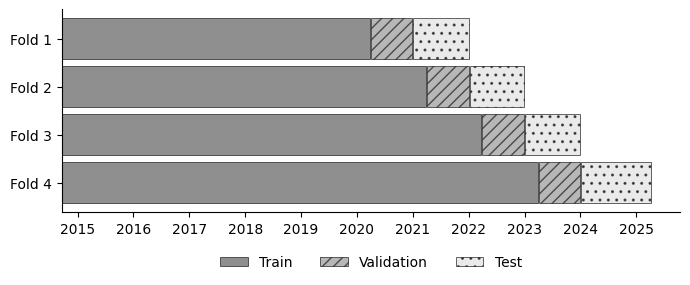

In [5]:
# fold-split visualization
def to_dt(d):
    return datetime.strptime(d, "%Y-%m-%d")

# Define styles (Grayscale + Hatching)
style_map = {
    "train": {"color": "#444444", "hatch": None, "label": "Train"},
    "val":   {"color": "#888888", "hatch": "///", "label": "Validation"},
    "test":  {"color": "#DDDDDD", "hatch": "..", "label": "Test"}
}

fig, ax = plt.subplots(figsize=(7, 3))
y_pos = range(len(FOLDS))
bar_height = 0.85 

for i, fold in enumerate(FOLDS):
    for split in ["train", "val", "test"]:
        start, end = map(to_dt, fold[split])
        style = style_map[split]
        ax.barh(
            i, end - start, left=start, height=bar_height, color=style["color"],
            hatch=style["hatch"], edgecolor="black", linewidth=0.7, 
            label=style["label"] if i == 0 else None, alpha=0.6
        )

ax.set_yticks(y_pos)
# This maps the index (0, 1, 2...) to "Fold 1, Fold 2, Fold 3..."
ax.set_yticklabels([f"Fold {i+1}" for i in y_pos], fontsize=10)
ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(fontsize=10)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), 
          ncol=3, frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig("figures/train_test_splits.pdf")
plt.show()

### **4) Model Architecture Pipelines** <a id="4-pipelines"></a>

In [6]:
def make_xy(X, y, dates, lookback, start, end):
    """Generates 3D sequences for LSTM training within specific date bounds.""" 
    mask = (dates >= start) & (dates <= end)
    Xs, ys, ds = [], [], []
    for i in range(lookback, len(dates)):
        if mask[i]:
            Xs.append(X[i-lookback:i])
            ys.append(y[i])
            ds.append(dates[i])
    return np.array(Xs, np.float32), np.array(ys, np.float32), pd.to_datetime(ds)

# The build_model function has been improved to consider 2 different optimisers an the clipping gradient
def build_model(lookback, n_feat, units, dropout, lr, optimizer_name="Adam"):
    """Defines a Sequential LSTM architecture for univariate regression."""
    model = tf.keras.Sequential([
        layers.Input((lookback, n_feat)),
        layers.LSTM(units),
        layers.Dropout(dropout),
        layers.Dense(1)
    ])
    
    # Dynamically select the optimizer and Add clipnorm=1.0 to prevent exploding gradients
    # Clipping forces the model to learn from the trend of the macro variables rather than the shocks
    if optimizer_name == "Adam":
        opt = tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0)
    elif optimizer_name == "RMSprop":
        opt = tf.keras.optimizers.RMSprop(learning_rate=lr)
    else:
        opt = tf.keras.optimizers.RMSprop(learning_rate=lr, clipnorm=1.0) # Default fallback
        
    model.compile(optimizer=opt, loss="mse")
    return model    


### **5) LSTM Training** <a id="5-lstm"></a>

Hyperparameter Optimization: Optuna Search Space

In [7]:
# Hyperparameters have been modified
"""
- shuffle=False has been added to both model and final_model to keep the ordering of the time series
- early stopping has been tested on the final_model with a small validation set (validation_split=0.1). 
  However, given the ordering of the time series, it has been prefered to not consider early stopping in the final 
  model and to extract the actual convergence epoch in our trial. Considering an arbitrary epoch would have push the 
  final model into over or under-fitting.
"""
# Fix all seeds
def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

def run_fold(fold, run_idx):
    run_seed = SEED + run_idx
    name = fold["name"]
    tr0, tr1 = fold["train"]
    va0, va1 = fold["val"]
    te0, te1 = fold["test"]

    # Scale features using TRAIN only
    scaler = StandardScaler().fit(data.loc[tr0:tr1, features])
    X_scaled = scaler.transform(data[features])

    def objective(trial):
        set_all_seeds(run_seed) # fixes all randomness
        optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "RMSprop"])
        lookback = trial.suggest_categorical("lookback", [4, 8, 13])  # For a weekly prediction of Bitcoin, 13 weeks is enough 
        # units = trial.suggest_categorical("units", [8, 16, 32, 64]) # 64 units was not considered at first, but the model was pushed close to the boundaries too many time, so including it allows the model to breath during training   
        units = trial.suggest_categorical("units", [8, 16, 32])  # Capping at 32 forces the model to compress the 17 variables. It no longer has the "storage space" to remember noise, so it must focus on the most persistent macro-signals          
        # dropout botom was originally 0.05, but was increased to 0.1 based on training to make sure it does not select arbitrarily a couple of covariates
        # dropout was then raised to 0.45 to handle noise from 16 covariates (raised to 0.5 was considered at some point as some best trials were flirting with 0.45)
        dropout = trial.suggest_float("dropout", 0.1, 0.45) 
        lr = trial.suggest_float("lr", 1e-4, 1e-3, log=True) # Tighter upper bound (8e-4, 6e-4) were first considered for stability (but raisd to 0.001 as some best trials were stuck)
        batch = trial.suggest_categorical("batch", [8, 16])  
        #recurrent_dropout = trial.suggest_float("recurrent_dropout", 0.0, 0.15) # no need in our specific case of Bitcoin

        Xtr, ytr, _ = make_xy(X_scaled, y_all, dates, lookback, tr0, tr1)
        Xva, yva, _ = make_xy(X_scaled, y_all, dates, lookback, va0, va1)
        if len(Xtr) < 20:
            return 1e9

        model = build_model(lookback, Xtr.shape[-1], units, dropout, lr, optimizer_name)
        # increasing patience from 10 to 15 to ensure the model doesn't stop too early before it has found that more robust, generalized solution.
        # Callbacks: Early Stopping + LR Scheduler
        es = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)
        # Reduces LR by half if validation loss stalls for 8 epochs (lowering patience to 8 in this case)
        reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-5, verbose=0)
        
        history = model.fit(
            Xtr, ytr,
            validation_data=(Xva, yva),
            epochs=150,
            batch_size=batch,
            shuffle=False,
            verbose=0,
            #callbacks=[es]
            callbacks=[es, reduce_lr] # includes LR scheduler
        )

        # Capture how many epochs it actually ran
        actual_epochs = len(history.epoch)
      
        # Store this as a "user attribute" in the Optuna trial
        trial.set_user_attr("epochs", actual_epochs)
        
        # Return the validation MSE for Optuna to minimize
        pred = model.predict(Xva, verbose=0).ravel()
        return mean_squared_error(yva, pred)


    # Optuna hyperparameter search
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=N_TRIALS)
    best = study.best_params
    print(f"{name}_run{run_idx} best params: {best}")

    # Extract the actual convergence point from our trials
    all_epochs = [t.user_attrs["epochs"] for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    avg_epochs = int(np.mean(all_epochs))
    print(f"Average Epochs across trials: {avg_epochs}")
    
    # --- Final fit on TRAIN+VAL ---
    scaler_tv = StandardScaler().fit(data.loc[tr0:va1, features])
    X_scaled_tv = scaler_tv.transform(data[features])

    lookback = best["lookback"]
    Xtv, ytv, _ = make_xy(X_scaled_tv, y_all, dates, lookback, tr0, va1)
    Xte, yte, dte = make_xy(X_scaled_tv, y_all, dates, lookback, te0, te1)

    set_all_seeds(run_seed)
    final_model = build_model(lookback, Xtv.shape[-1], best["units"], best["dropout"], best["lr"], best["optimizer"])    # best["optimizer"] has been added

    # CHANGES: Remove validation set that can degrade the RSME and do NOT use EarlyStopping (because we have no validation set).
    # Instead, we train for a fixed number of epochs (from Optuna): avg_epochs
    final_model.fit(
        Xtv, ytv,
        epochs=avg_epochs,
        batch_size=best["batch"],
        shuffle=False,
        verbose=0
    )

    # --- Test predictions ---
    y_pred = final_model.predict(Xte, verbose=0).ravel()

    mse = mean_squared_error(yte, y_pred)
    rmse = float(np.sqrt(mse))
    mae  = float(mean_absolute_error(yte, y_pred))
    r2   = float(r2_score(yte, y_pred))

    # --- Save model and scaler for SHAP ---
    fold_dir = os.path.join(SAVE_DIR, f"{name}_run{run_idx}")
    os.makedirs(fold_dir, exist_ok=True)
    final_model.save(os.path.join(fold_dir, "model.keras"))
    joblib.dump(scaler_tv, os.path.join(fold_dir, "scaler.joblib"))

    rng = np.random.default_rng(SEED)
    bg_idx = rng.choice(len(Xtv), size=min(N_BACKGROUND, len(Xtv)), replace=False)
    X_background = Xtv[bg_idx]

    np.save(os.path.join(fold_dir, "X_background.npy"), X_background)
    np.save(os.path.join(fold_dir, "X_explain.npy"), Xte)
    np.save(os.path.join(fold_dir, "dates_explain.npy"), dte.values)
    pd.Series({"lookback": lookback, "features": features}).to_json(os.path.join(fold_dir, "meta.json"))

    # --- Return metrics and predictions for DM test ---
    return {
        "fold": f"{name}_run{run_idx}",
        "best_optimizer": best["optimizer"],
        "n_test": int(len(yte)),
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "best_val_loss": study.best_value,
        "best_params": best,
        "y_pred_values": y_pred,
        "y_test_values": yte
    }

In [ ]:
# WARNING
"""
- !!! 12_ARIMA_GARCH.ipynb MUST BE RUN FIRST to generate the repository arima_outputs"
"""

# Note on Diebold-Mariano (DM) test
"""
- if p-value <0.05 then the difference in predictive accuracy between LSTM and ARIMA is significant.
- As our macro-LSTM will perform worse than the ARIMA for weekly returns, we want p-value > 0.05.
- If p-value > 0.05, this means that the macro-LSTM is not significantly performing worse than ARIMA.
"""

# Note on Emsemble RMSE
"""
- Here, run the DM test on each run in each fold, but most importantly, we also measure an Ensemble RMSE.
- DM test is run on the Ensemble RMSE, which is more statistically significant and more important than single runs.
"""

def diebold_mariano(e1, e2, h=1):
    """
    Diebold-Mariano test for equal predictive accuracy.
    e1, e2: forecast errors from two models
    h: forecast horizon (1 for 1-step ahead)
    """
    e1 = np.asarray(e1)
    e2 = np.asarray(e2)

    # Loss differential (squared error)
    d = e1**2 - e2**2

    T = len(d)
    mean_d = np.mean(d)

    # Variance of loss differential
    gamma0 = np.var(d, ddof=1)

    # For h=1 this simplifies (no autocovariance terms needed)
    DM_stat = mean_d / np.sqrt(gamma0 / T)

    p_value = 2 * (1 - stats.norm.cdf(np.abs(DM_stat)))

    return DM_stat, p_value

def load_arima_predictions(fold_name):
    y_true = np.load(f"data/arima_outputs/{fold_name}_y_true.npy")
    y_pred_arima = np.load(f"data/arima_outputs/{fold_name}_y_pred_arima.npy")
    return y_true, y_pred_arima


metrics_rows = []

for fold in FOLDS:
    all_run_preds = []  # Reset for each fold
    y_true_lstm = None  # To capture the true values for this fold

    # RUN INDIVIDUAL MODELS
    for r in range(1, N_RUNS + 1):
        res = run_fold(fold, r)
        
        all_run_preds.append(res["y_pred_values"])
        y_true_lstm = res["y_test_values"] # Stays same across runs

        # Load ARIMA predictions for individual DM check
        y_true_arima, y_pred_arima = load_arima_predictions(fold["name"])

        # ALIGNMENT CHECK
        if len(y_true_arima) != len(y_true_lstm):
            print(f"[WARNING] Length mismatch in {fold['name']}")
            print("ARIMA length:", len(y_true_arima))
            print("LSTM length:", len(res["y_test_values"]))

            # Trim ARIMA to match LSTM test window (only useful in FOLD4)
            print("Trimming ARIMA to match LSTM")
            y_true_arima = y_true_arima[-len(y_true_lstm):]
            y_pred_arima = y_pred_arima[-len(y_true_lstm):]

        # Final safety assertion
        assert len(y_true_arima) == len(res["y_test_values"]), \
            "Still misaligned after trimming!"

        # Compute DM test for each run
        DM_stat, p_val = diebold_mariano(
            e1=y_true_lstm - res["y_pred_values"],   # LSTM errors
            e2=y_true_arima - y_pred_arima,          # ARIMA errors
            h=1
        )

        res.update({"DM_stat": DM_stat, "DM_pvalue": p_val})
        metrics_rows.append(res)

        print(f'{res["fold"]} run {r} | RMSE={res["RMSE"]:.6f} | DM p-value={p_val:.4f}')

    # ENSEMBLE CALCULATION (After the 5 runs are done)
    y_pred_ensemble = np.mean(all_run_preds, axis=0)
    
    # Calculate Ensemble RMSE
    ens_rmse = np.sqrt(mean_squared_error(y_true_lstm, y_pred_ensemble))    
    # Calculate Ensemble MAE
    ens_mae = mean_absolute_error(y_true_lstm, y_pred_ensemble)
     # Calculate Ensemble R2 Score
    ens_r2 = r2_score(y_true_lstm, y_pred_ensemble)
    
    # Reload ARIMA for Ensemble DM check
    y_true_arima, y_pred_arima = load_arima_predictions(fold["name"])
    y_true_arima = y_true_arima[-len(y_true_lstm):]
    y_pred_arima = y_pred_arima[-len(y_true_lstm):]

    # Compute Ensemble DM
    ens_DM_stat, ens_p_val = diebold_mariano(
        e1=y_true_lstm - y_pred_ensemble, 
        e2=y_true_arima - y_pred_arima, 
        h=1
    )

    # CREATE ENSEMBLE ENTRY
    ensemble_res = {
        "fold": f"{fold['name']}_ens",
        "run_id": "Ensemble",   # String ID to distinguish from numeric runs
        "RMSE": ens_rmse,
        "MAE": ens_mae,
        "R2": ens_r2,
        "DM_stat": ens_DM_stat,
        "DM_pvalue": ens_p_val,
        "is_ensemble": True    # Helper flag for later filtering
    }

    # Append to your main results list
    metrics_rows.append(ensemble_res)

    print(f'--- {fold["name"]} ENSEMBLE ---')
    print(f'RMSE: {ens_rmse:.4f} | MAE: {ens_mae:.4f} | R2: {ens_r2:.4f} | DM p-val: {ens_p_val:.4f}')

    # IDENTIFY MEDIAN RUN FOR SHAP (Beeswarm representation)
    # Search for any row where the 'fold' string contains 'fold1', 'fold2', etc. AND excludes the ensemble row
    current_fold_indiv = [
        m for m in metrics_rows 
        if fold["name"] in m["fold"] and "_ens" not in m["fold"]
    ]
    
    if len(current_fold_indiv) > 0:
        rmses = [m["RMSE"] for m in current_fold_indiv]
        
        # Sort indices by RMSE value
        sorted_indices = np.argsort(rmses)
        
        # Select the middle index (position 2 out of 5)
        median_pos = len(rmses) // 2
        median_idx = sorted_indices[median_pos] 
        
        # Get the full name (e.g., 'fold1_run3')
        target_run_name = current_fold_indiv[median_idx]["fold"]
        median_rmse_val = current_fold_indiv[median_idx]["RMSE"]
        
        print(f'>>> Recommended SHAP Model for {fold["name"]}: {target_run_name}')
        print(f'>>> Median RMSE: {median_rmse_val:.6f}')
    else:
        print(f'>>> [ERROR] No individual runs found for {fold["name"]} in metrics_rows.')

    # Save Results for each fold
    metrics_df_row = pd.DataFrame(metrics_rows).set_index("fold").sort_index()
    metrics_df_row.to_csv(f"data/LSTM_{fold["name"]}_saved_results.csv")

# IMPORTANT Note:
"""
- The MEDIAN run can be used for the Beeswarm representation
- The mean and strandard deviation measured across the 5 runs can be used for the bar plot representation
"""

### **6) Print Results** <a id="6-results"></a>


In [8]:
files = [
    "data/LSTM_fold1_saved_results.csv",
    "data/LSTM_fold2_saved_results.csv",
    "data/LSTM_fold3_saved_results.csv",
    "data/LSTM_fold4_saved_results.csv"
]

df_list = [pd.read_csv(f) for f in files]

# Stack them vertically
# ignore_index=True ensures the row numbers go from 0 to 23 (6 rows * 4 folds)
metrics_df = pd.concat(df_list, axis=0, ignore_index=True)#.set_index("fold").sort_index()
display(metrics_df[["fold", "RMSE", "MAE","best_val_loss", "DM_pvalue", "best_params"]])

,fold,RMSE,MAE,best_val_loss,DM_pvalue,best_params
0,fold1_ens,0.114239,0.085739,NaN,0.389496,NaN
1,fold1_run1,0.128947,0.103184,0.016593,0.978094,"{'optimizer': 'RMSprop', 'lookback': 13, 'unit..."
2,fold1_run2,0.136705,0.100517,0.005019,0.710281,"{'optimizer': 'RMSprop', 'lookback': 4, 'units..."
3,fold1_run3,0.166276,0.124925,0.006412,0.127193,"{'optimizer': 'RMSprop', 'lookback': 4, 'units..."
4,fold1_run4,0.119577,0.091035,0.004914,0.571276,"{'optimizer': 'RMSprop', 'lookback': 4, 'units..."
5,fold1_run5,0.116831,0.093148,0.004440,0.407972,"{'optimizer': 'Adam', 'lookback': 13, 'units':..."
6,fold2_ens,0.095666,0.081788,NaN,0.584618,NaN
7,fold2_run1,0.133169,0.115046,0.008342,0.003416,"{'optimizer': 'RMSprop', 'lookback': 8, 'units..."
8,fold2_run2,0.128850,0.096745,0.014776,0.051711,"{'optimizer': 'RMSprop', 'lookback': 4, 'units..."
9,fold2_run3,0.111925,0.087499,0.009115,0.152311,"{'optimizer': 'Adam', 'lookback': 13, 'units':..."


In [9]:
# UNPACK PARAMS
def unpack_params(param_str):
    if pd.isna(param_str) or param_str == "NaN":
        return "—", "—", "—"
    try:
        # Convert string representation of dict to actual dict
        d = ast.literal_eval(param_str)
        opt = d.get('optimizer', '—')
        lbk = d.get('lookback', '—')
        units = d.get('units', '—')
        return opt, lbk, units
    except:
        return "—", "—", "—"

# Latex Table
print("\\begin{table}[ht]")
print("\\centering")
print("\\caption{LSTM Ensemble and Individual Run Performance}")
print("\\label{tab:lstm_metrics}")
print("\\begin{tabular}{@{}llcccccc@{}}")
print("\\toprule")
print("Fold & Model/Run & RMSE & MAE & Val. Loss & Opt. & Lbk. & Units \\\\ \\midrule")

for i, row in metrics_df.iterrows():
    # Identify Fold and Type
    f_label = str(row['fold']).split('_')[0].replace('fold', 'F')
    is_ens = "_ens" in str(row['fold'])
    run_label = "\\textbf{Ensemble}" if is_ens else str(row['fold']).split('_')[1].replace('run', 'R')
    
    # Handle Numeric Values
    rmse = f"{row['RMSE']:.4f}"
    mae = f"{row['MAE']:.4f}"
    # Use — for NaN/missing values
    v_loss = f"{row['best_val_loss']:.4f}" if pd.notna(row['best_val_loss']) else "—"
    
    # Unpack Hyperparameters (No LR)
    opt, lbk, units = unpack_params(row['best_params'])
    
    # Optional: Add space between folds for readability
    if is_ens and i > 0:
        print("\\addlinespace[0.5em]")

    # Print the row
    print(f"{f_label} & {run_label} & {rmse} & {mae} & {v_loss} & {opt} & {lbk} & {units} \\\\")

print("\\bottomrule")
print("\\end{tabular}")
print("\\end{table}")

\begin{table}[ht]
\centering
\caption{LSTM Ensemble and Individual Run Performance}
\label{tab:lstm_metrics}
\begin{tabular}{@{}llcccccc@{}}
\toprule
Fold & Model/Run & RMSE & MAE & Val. Loss & Opt. & Lbk. & Units \\ \midrule
F1 & \textbf{Ensemble} & 0.1142 & 0.0857 & — & — & — & — \\
F1 & R1 & 0.1289 & 0.1032 & 0.0166 & RMSprop & 13 & 16 \\
F1 & R2 & 0.1367 & 0.1005 & 0.0050 & RMSprop & 4 & 32 \\
F1 & R3 & 0.1663 & 0.1249 & 0.0064 & RMSprop & 4 & 32 \\
F1 & R4 & 0.1196 & 0.0910 & 0.0049 & RMSprop & 4 & 16 \\
F1 & R5 & 0.1168 & 0.0931 & 0.0044 & Adam & 13 & 8 \\
\addlinespace[0.5em]
F2 & \textbf{Ensemble} & 0.0957 & 0.0818 & — & — & — & — \\
F2 & R1 & 0.1332 & 0.1150 & 0.0083 & RMSprop & 8 & 16 \\
F2 & R2 & 0.1288 & 0.0967 & 0.0148 & RMSprop & 4 & 8 \\
F2 & R3 & 0.1119 & 0.0875 & 0.0091 & Adam & 13 & 32 \\
F2 & R4 & 0.1275 & 0.1058 & 0.0081 & Adam & 13 & 16 \\
F2 & R5 & 0.1594 & 0.1355 & 0.0072 & Adam & 13 & 16 \\
\addlinespace[0.5em]
F3 & \textbf{Ensemble} & 0.0750 & 0.0569 & — & — & 

In [10]:
folds = ['fold1', 'fold2', 'fold3', 'fold4']
lstm_ensembles = {}

for f in folds:
    # Look for the row where the 'fold' column exactly matches 'foldX_ens'
    # We use .iloc[0] to convert the single-row dataframe into a Series
    ens_row = metrics_df[metrics_df["fold"] == f"{f}_ens"].iloc[0]
    
    lstm_ensembles[f] = {
        'RMSE': float(ens_row['RMSE']),
        'MAE': float(ens_row['MAE']),
        'DM_p': float(ens_row['DM_pvalue'])
    }

# ARIMA DATA
arima_folder = 'data/arima_outputs/'
arima_orders = ["(2, 0, 2)", "(2, 0, 2)", "(2, 0, 2)", "(0, 0, 1)"]
arima_results = {}

for i, f in enumerate(folds, 1):
    y_true = np.load(f"{arima_folder}fold{i}_y_true.npy")
    y_pred = np.load(f"{arima_folder}fold{i}_y_pred_arima.npy")
    
    arima_results[f] = {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'Order': arima_orders[i-1]
    }

# LATEX TABLE
print("\\begin{tabular}{@{}lcccccc@{}}")
print("\\toprule")
print(" & \\multicolumn{3}{c}{LSTM Ensemble} & \\multicolumn{3}{c}{ARIMA (Baseline)} \\\\")
print("\\cmidrule(lr){2-4} \\cmidrule(l){5-7}")
print("Fold & RMSE & MAE & DM $p$-val & RMSE & MAE & Order $(p,d,q)$ \\\\ \\midrule")

# Lists to store values for final mean/std calculation
all_l_rmse, all_l_mae = [], []
all_a_rmse, all_a_mae = [], []

for f in folds:
    l = lstm_ensembles[f]
    a = arima_results[f]
    
    all_l_rmse.append(l['RMSE'])
    all_l_mae.append(l['MAE'])
    all_a_rmse.append(a['RMSE'])
    all_a_mae.append(a['MAE'])
    
    l_rmse_str = f"{l['RMSE']:.4f}" if l['RMSE'] < a['RMSE'] else f"{l['RMSE']:.4f}"
    
    print(f" {f[-1]} & {l_rmse_str} & {l['MAE']:.4f} & {l['DM_p']:.3f} & "
          f"{a['RMSE']:.4f} & {a['MAE']:.4f} & {a['Order']} \\\\")

print("\\midrule")

# Final Overall Rows
print(f"Overall (Mean) & {np.mean(all_l_rmse):.4f} & {np.mean(all_l_mae):.4f} & --- & "
      f"{np.mean(all_a_rmse):.4f} & {np.mean(all_a_mae):.4f} & --- \\\\")

print(f"Overall (Std Dev) & ({np.std(all_l_rmse):.3f}) & ({np.std(all_l_mae):.3f}) & --- & "
      f"({np.std(all_a_rmse):.3f}) & ({np.std(all_a_mae):.3f}) & --- \\\\")

print("\\bottomrule")
print("\\end{tabular}")

\begin{tabular}{@{}lcccccc@{}}
\toprule
 & \multicolumn{3}{c}{LSTM Ensemble} & \multicolumn{3}{c}{ARIMA (Baseline)} \\
\cmidrule(lr){2-4} \cmidrule(l){5-7}
Fold & RMSE & MAE & DM $p$-val & RMSE & MAE & Order $(p,d,q)$ \\ \midrule
 1 & 0.1142 & 0.0857 & 0.389 & 0.1295 & 0.1067 & (2, 0, 2) \\
 2 & 0.0957 & 0.0818 & 0.585 & 0.0876 & 0.0623 & (2, 0, 2) \\
 3 & 0.0750 & 0.0569 & 0.561 & 0.0671 & 0.0477 & (2, 0, 2) \\
 4 & 0.0735 & 0.0590 & 0.063 & 0.0651 & 0.0497 & (0, 0, 1) \\
\midrule
Overall (Mean) & 0.0896 & 0.0709 & --- & 0.0873 & 0.0666 & --- \\
Overall (Std Dev) & (0.017) & (0.013) & --- & (0.026) & (0.024) & --- \\
\bottomrule
\end{tabular}
